<a href="https://colab.research.google.com/github/ElofssonLab/kb8029-book/blob/main/notebooks/day08-ml-foundations-and-pytorch.ipynb" style="display:inline-block;padding:10px 18px;background-color:#F9AB00;color:#000000;font-weight:bold;text-decoration:none;border-radius:6px;font-family:sans-serif;font-size:14px;">&#9654;&nbsp; Open in Google Colab</a>

# Day 8 — Machine Learning Foundations & Practical PyTorch, in code {.unnumbered}

This notebook works through the day's ideas concretely: splitting data
for training/validation/testing, computing the standard classifier
evaluation metrics, visualizing the activation functions that replace a
perceptron's step function, and finally building a real PyTorch
`nn.Module` classifier for a genuine multi-class biological problem —
predicting a human protein's subcellular localization from its sequence
— defined and shape-checked here, but **not yet trained**. Day 9's
notebook picks up this exact model and dataset and trains it.

In [1]:
import re
import numpy as np
import requests
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, precision_recall_fscore_support,
    roc_auc_score, matthews_corrcoef,
)

torch.manual_seed(0)
np.random.seed(0)
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold

## Train / validation / test splits

Supervised learning fits a model to labelled examples; unsupervised
learning (not used in this course) finds structure with no labels at
all. Every supervised model in this course from here on needs data split
three ways: a **training** set to fit the weights, a **validation** set
to check progress and tune choices like the regularization settings Day
9 introduces, and a **test** set touched only once, at the very end, to
report a fair final number. Mixing these up — for example, tuning a
choice based on test-set performance — silently inflates how good the
model looks.

A quick mechanical check with `scikit-learn`'s `train_test_split`, splitting
a small array 70/15/15:

In [2]:
toy = np.arange(20)
toy_train, toy_tmp = train_test_split(toy, test_size=0.30, random_state=0)
toy_val, toy_test = train_test_split(toy_tmp, test_size=0.5, random_state=0)
print("train:", sorted(toy_train.tolist()))
print("val:  ", sorted(toy_val.tolist()))
print("test: ", sorted(toy_test.tolist()))
print(f"sizes: {len(toy_train)} / {len(toy_val)} / {len(toy_test)} (train/val/test)")

train: [0, 2, 3, 4, 5, 6, 7, 9, 11, 12, 13, 14, 15, 16]
val:   [8, 10, 18]
test:  [1, 17, 19]
sizes: 14 / 3 / 3 (train/val/test)


### Further reading

- Wikipedia, [Training, validation, and test data sets](https://en.wikipedia.org/wiki/Training,_validation,_and_test_data_sets)
- Wikipedia, [Supervised learning](https://en.wikipedia.org/wiki/Supervised_learning) and [Unsupervised learning](https://en.wikipedia.org/wiki/Unsupervised_learning)

## From the perceptron's step function to smooth activations

Day 6's perceptron used a **step function**: output 1 if $z > 0$, else 0.
That is exactly what a biological neuron does at a coarse level too — a
neuron sums its incoming synaptic potentials and fires an action
potential only once that sum crosses a threshold. But a step function's
derivative is zero everywhere except one undefined point at $z=0$ — it
gives gradient descent nothing to work with. Replacing it with a smooth,
differentiable S-shaped function keeps the same "sum inputs, decide"
computation, but makes it trainable by gradient descent (Day 9's
backpropagation needs exactly this).

Three activation functions used throughout the rest of this course:

$$
\text{sigmoid: } \sigma(x) = \frac{1}{1+e^{-x}} \qquad
\tanh(x) = 2\sigma(2x) - 1 \qquad
\text{ReLU: } f(x) = \max(0, x)
$$

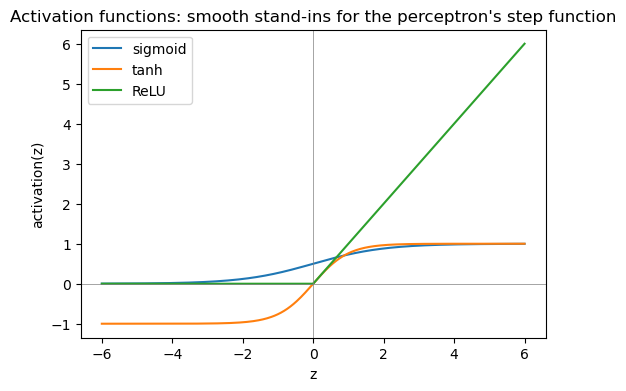

In [3]:
def sigmoid(x): return 1.0 / (1.0 + np.exp(-x))
def relu(x): return np.maximum(0, x)

x = np.linspace(-6, 6, 400)
import matplotlib.pyplot as plt
plt.figure(figsize=(6, 4))
plt.plot(x, sigmoid(x), label="sigmoid")
plt.plot(x, np.tanh(x), label="tanh")
plt.plot(x, relu(x), label="ReLU")
plt.axhline(0, color="grey", linewidth=0.5)
plt.axvline(0, color="grey", linewidth=0.5)
plt.legend()
plt.title("Activation functions: smooth stand-ins for the perceptron's step function")
plt.xlabel("z"); plt.ylabel("activation(z)")
plt.savefig("../figs/day08-activation-functions.png", dpi=150, bbox_inches="tight")
plt.show()

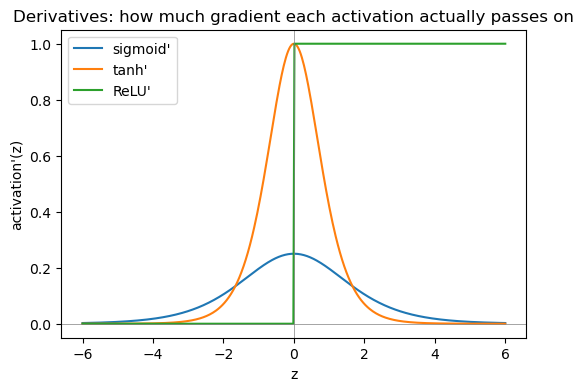

sigmoid'(0) = 0.25  sigmoid'(6) = 0.002466509291359931
tanh'(0)    = 1.0  tanh'(6)    = 2.4576547405286142e-05
ReLU'(-1)   = 0.0  ReLU'(1)    = 1.0


In [4]:
def sigmoid_prime(x):
    s = sigmoid(x)
    return s * (1 - s)

def tanh_prime(x):
    return 1 - np.tanh(x)**2

def relu_prime(x):
    return (x > 0).astype(float)

plt.figure(figsize=(6, 4))
plt.plot(x, sigmoid_prime(x), label="sigmoid'")
plt.plot(x, tanh_prime(x), label="tanh'")
plt.plot(x, relu_prime(x), label="ReLU'")
plt.axhline(0, color="grey", linewidth=0.5)
plt.axvline(0, color="grey", linewidth=0.5)
plt.legend()
plt.title("Derivatives: how much gradient each activation actually passes on")
plt.xlabel("z"); plt.ylabel("activation'(z)")
plt.savefig("../figs/day08-activation-derivatives.png", dpi=150, bbox_inches="tight")
plt.show()

print("sigmoid'(0) =", sigmoid_prime(np.array([0.0]))[0], " sigmoid'(6) =", sigmoid_prime(np.array([6.0]))[0])
print("tanh'(0)    =", tanh_prime(np.array([0.0]))[0],    " tanh'(6)    =", tanh_prime(np.array([6.0]))[0])
print("ReLU'(-1)   =", relu_prime(np.array([-1.0]))[0],   " ReLU'(1)    =", relu_prime(np.array([1.0]))[0])

**Trade-offs, concretely (from the numbers above):**

| Activation | Range | Zero-centered? | Saturates? | Cheap to compute? | Known problem |
|---|---|---|---|---|---|
| Sigmoid | $(0,1)$ | No | Both ends ($\lvert z\rvert \to \infty$) | Yes | Vanishing gradient; non-zero-centered output slows convergence in deeper nets |
| Tanh | $(-1,1)$ | Yes | Both ends | Yes | Still vanishing gradient, though less severe than sigmoid |
| ReLU | $[0,\infty)$ | No | Only for $z<0$ (gradient exactly 0 there) | Very (no exponential) | "Dying ReLU" -- a unit stuck with $z<0$ for every input gets zero gradient forever and never recovers |

Sigmoid's derivative peaks at just $0.25$ (at $z=0$) and is already
below $0.01$ by $|z|=6$ — printed above. Tanh's peaks at $1.0$ and is
zero-centered, which is why it was historically preferred over sigmoid
for *hidden* layers (sigmoid is still standard for a binary *output*
layer, where a $(0,1)$ range is exactly what's wanted). ReLU's
derivative is either exactly $0$ or exactly $1$ — cheap, and never
shrinks for positive inputs — but that same all-or-nothing behavior is
what causes "dying ReLU": a unit whose weights put it firmly in $z<0$
territory for its entire training set gets a zero gradient and can
never come back. Modern practice often reaches for **Leaky ReLU**
($f(z) = \max(0.01z, z)$, a small nonzero slope for $z<0$) or **GELU**
(a smooth ReLU-like curve used in transformers) specifically to fix
this — mentioned here as pointers, not needed for this course's own
networks.

Sigmoid and tanh both saturate (flatten, gradient near zero) for large
$|x|$ — the source of the "vanishing gradient" problem Day 9 tackles.
ReLU is unbounded for $x>0$, which avoids saturating on that side, one
reason it is the default choice in modern networks.

### Further reading

- Wikipedia, [Activation function](https://en.wikipedia.org/wiki/Activation_function)
- Wikipedia, [Biological neuron model](https://en.wikipedia.org/wiki/Biological_neuron_model) — the "sum inputs, fire past a threshold" idea a perceptron is a deliberate simplification of

## From binary to multi-class: softmax

Day 6's perceptron/linear model produced one number, thresholded into a
yes/no decision. Many real problems — including the case study below —
have more than two classes. **Softmax** generalizes this: given $K$ raw
scores (logits) $z_1, \ldots, z_K$, one per class,

$$
\text{softmax}(z)_k = \frac{e^{z_k}}{\sum_{j=1}^K e^{z_j}}
$$

turns them into $K$ positive numbers that sum to 1 — a probability
distribution over classes. In PyTorch practice, a classification model's
final layer outputs raw logits (no softmax applied), and the loss
function (`nn.CrossEntropyLoss`) applies softmax internally as part of
computing the loss — softmax is applied explicitly only when actual
probabilities are needed afterward (e.g. for the ROC/AUROC metric
below).

### Further reading

- d2l.ai, [Softmax Regression](https://d2l.ai/chapter_linear-classification/softmax-regression.html) — CC BY-SA 4.0

## Evaluating a classifier

Once a model makes predictions, how good are they? A **confusion
matrix** cross-tabulates true vs. predicted class. From it:

$$
\text{precision} = \frac{TP}{TP+FP} \qquad
\text{recall} = \frac{TP}{TP+FN} \qquad
F_1 = \frac{2 \cdot \text{precision} \cdot \text{recall}}{\text{precision}+\text{recall}}
$$

The **Matthews correlation coefficient (MCC)** summarizes the whole
confusion matrix in one number robust to class imbalance, ranging from
$+1$ (perfect) through $0$ (no better than random) to $-1$ (perfectly
wrong). The **ROC curve** plots true-positive rate against false-positive
rate as a decision threshold sweeps across the predicted probabilities;
the area underneath (**AUROC**) is $0.5$ for a random classifier and $1.0$
for a perfect one.

These are computed below on the case study network's *own* predictions
— defined next, but not yet trained, so this also shows concretely what
"no better than chance" looks like in each of these numbers, as the
baseline Day 9's trained version will be compared against.

### Further reading

- Wikipedia, [Confusion matrix](https://en.wikipedia.org/wiki/Confusion_matrix), [F-score](https://en.wikipedia.org/wiki/F-score), [Matthews correlation coefficient](https://en.wikipedia.org/wiki/Phi_coefficient), [Receiver operating characteristic](https://en.wikipedia.org/wiki/Receiver_operating_characteristic)

## Case study: subcellular localization

A real multi-class classification problem: predict which part of the
cell a human protein localizes to, from its amino-acid sequence alone —
also, not incidentally, the same *kind* of output Day 9's secondary
structure payoff needs (a small number of discrete classes per input).

Five classes, fetched live from **UniProt** (reviewed human entries,
50-500 residues, restricted to entries whose subcellular-location
annotation lists exactly one clean location term — no dual-localizing or
isoform-specific entries, to keep each label unambiguous):

In [5]:
UNIPROT_CLASSES = {
    "Cytoplasm": "SL-0086",
    "Nucleus": "SL-0191",
    "Mitochondrion": "SL-0173",
    "Secreted": "SL-0243",
    "Cell membrane": "SL-0039",
}
CLASS_NAMES = list(UNIPROT_CLASSES.keys())

def fetch_uniprot(sl_code, size=500):
    query = f"organism_id:9606 AND reviewed:true AND cc_scl_term:{sl_code} AND length:[50 TO 500]"
    r = requests.get(
        "https://rest.uniprot.org/uniprotkb/search",
        params={"query": query, "fields": "accession,sequence,cc_subcellular_location",
                "format": "tsv", "size": size},
        timeout=60,
    )
    r.raise_for_status()
    rows = []
    for line in r.text.strip().split("\n")[1:]:
        parts = line.split("\t")
        if len(parts) == 3:
            rows.append(tuple(parts))  # (accession, sequence, location_text)
    return rows

def is_unambiguous_single_location(location_text, target):
    """Keep only entries whose SUBCELLULAR LOCATION comment names exactly
    one location term (matching the target), ignoring free-text Notes,
    evidence-code tags, and skipping isoform-specific annotations."""
    location_text = re.sub(r"Note=.*", "", location_text)
    location_text = re.sub(r"\{[^}]*\}", "", location_text)
    if "Isoform" in location_text:
        return False
    terms = set()
    for statement in [s.strip() for s in location_text.split(".") if s.strip()]:
        body = statement.split(":", 1)[-1] if ":" in statement else statement
        top_term = re.split(r"[,;]", body)[0].strip()
        if top_term:
            terms.add(top_term)
    return len(terms) == 1 and next(iter(terms)) == target

sequences_by_class = {}
for class_name, sl_code in UNIPROT_CLASSES.items():
    raw = fetch_uniprot(sl_code)
    clean = [seq for _, seq, loc in raw if is_unambiguous_single_location(loc, class_name)]
    sequences_by_class[class_name] = clean
    print(f"{class_name:15s} raw hits: {len(raw):4d}   unambiguous single-location: {len(clean):4d}")

Cytoplasm       raw hits:  500   unambiguous single-location:  424


Nucleus         raw hits:  500   unambiguous single-location:  497


Mitochondrion   raw hits:  500   unambiguous single-location:  140


Secreted        raw hits:  500   unambiguous single-location:  488


Cell membrane   raw hits:  500   unambiguous single-location:  338


**Mitochondrion** is the limiting class — balance the dataset by taking
that many examples from every class, so accuracy and the confusion
matrix aren't distorted by class imbalance:

In [6]:
N_PER_CLASS = min(len(v) for v in sequences_by_class.values())
print("balancing every class to", N_PER_CLASS, "sequences")

rng = np.random.RandomState(0)
balanced_seqs, balanced_labels = [], []
for class_idx, class_name in enumerate(CLASS_NAMES):
    pool = sequences_by_class[class_name]
    chosen = rng.choice(len(pool), N_PER_CLASS, replace=False)
    for i in chosen:
        balanced_seqs.append(pool[i])
        balanced_labels.append(class_idx)

print("total balanced dataset:", len(balanced_seqs), "sequences,", len(CLASS_NAMES), "classes")

balancing every class to 140 sequences
total balanced dataset: 700 sequences, 5 classes


### One-hot encoding

Each sequence is encoded as a fixed-length one-hot matrix: 20 columns
(one per standard amino acid), one row per sequence position, truncated
or zero-padded to a fixed length of 150 residues. 150 is a deliberate
choice, not just "long enough" — the biological signals that determine
localization (signal peptides for secretion, mitochondrial targeting
sequences, nuclear localization signals) are overwhelmingly
**N-terminal**, so truncating to the first 150 residues keeps the
relevant signal for most sequences while keeping the input a manageable
size. The one-hot matrix is then flattened into a single vector per
sequence, since the network below is a plain fully-connected `nn.Module`,
not (yet) a network with any notion of sequence position.

In [7]:
AMINO_ACIDS = "ACDEFGHIKLMNPQRSTVWY"
AA_TO_INDEX = {aa: i for i, aa in enumerate(AMINO_ACIDS)}
SEQ_LEN = 150

def one_hot_encode(sequence, length=SEQ_LEN):
    encoded = np.zeros((length, len(AMINO_ACIDS)), dtype=np.float32)
    for position, residue in enumerate(sequence[:length]):
        if residue in AA_TO_INDEX:
            encoded[position, AA_TO_INDEX[residue]] = 1.0
    return encoded.flatten()

X = np.stack([one_hot_encode(s) for s in balanced_seqs])
y = np.array(balanced_labels)
print("X shape:", X.shape, "  (", len(balanced_seqs), "sequences x", SEQ_LEN, "positions x", len(AMINO_ACIDS), "amino acids, flattened )")
print("y shape:", y.shape)

X shape: (700, 3000)   ( 700 sequences x 150 positions x 20 amino acids, flattened )
y shape: (700,)


Splitting into train/validation/test (stratified, so each split keeps
the same 5-way class balance):

In [8]:
X_train, X_tmp, y_train, y_tmp = train_test_split(X, y, test_size=0.30, stratify=y, random_state=0)
X_val, X_test, y_val, y_test = train_test_split(X_tmp, y_tmp, test_size=0.5, stratify=y_tmp, random_state=0)
print(f"train: {len(X_train)}   val: {len(X_val)}   test: {len(X_test)}")

train: 490   val: 105   test: 105


### How stable is a single split, really?

The validation set above has only 105 proteins. To see whether that's
enough to trust a single accuracy number, refit a **fast baseline**
(logistic regression -- not the deep network above, which Day 9 trains;
this is just a quick classical classifier to check split stability
cheaply) across several different random splits, and watch how much the
validation accuracy moves around:

In [9]:
single_split_accuracies = []
for seed in range(10):
    Xt, Xtmp, yt, ytmp = train_test_split(X, y, test_size=0.30, stratify=y, random_state=seed)
    Xv, Xte, yv, yte = train_test_split(Xtmp, ytmp, test_size=0.5, stratify=ytmp, random_state=seed)
    clf = LogisticRegression(max_iter=2000, random_state=0)
    clf.fit(Xt, yt)
    acc = clf.score(Xv, yv)
    single_split_accuracies.append(acc)
    print(f"seed {seed}: validation accuracy = {acc:.3f}")

single_split_accuracies = np.array(single_split_accuracies)
print(f"\nacross 10 different single splits: mean = {single_split_accuracies.mean():.3f}, "
      f"std = {single_split_accuracies.std():.3f}, "
      f"range = [{single_split_accuracies.min():.3f}, {single_split_accuracies.max():.3f}]")

seed 0: validation accuracy = 0.581


seed 1: validation accuracy = 0.571
seed 2: validation accuracy = 0.552


seed 3: validation accuracy = 0.600


seed 4: validation accuracy = 0.571
seed 5: validation accuracy = 0.505


seed 6: validation accuracy = 0.533


seed 7: validation accuracy = 0.552
seed 8: validation accuracy = 0.610


seed 9: validation accuracy = 0.533

across 10 different single splits: mean = 0.561, std = 0.031, range = [0.505, 0.610]


### Cross-validation: averaging over multiple folds

**K-fold cross-validation** fixes this by using every example as
validation data exactly once: partition the training+validation data
(595 proteins, holding the 105-protein test set untouched throughout)
into $k=5$ roughly equal, class-stratified folds, train on the other
four each time, and average the $k$ resulting accuracies. It costs
$k\times$ the fitting time, but the resulting estimate — and its spread
across folds — is a genuinely more trustworthy picture of how this
model performs than any single split above:

In [10]:
X_cv = np.concatenate([X_train, X_val])
y_cv = np.concatenate([y_train, y_val])

kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
fold_accuracies = []
for fold, (train_idx, val_idx) in enumerate(kfold.split(X_cv, y_cv)):
    clf = LogisticRegression(max_iter=2000, random_state=0)
    clf.fit(X_cv[train_idx], y_cv[train_idx])
    acc = clf.score(X_cv[val_idx], y_cv[val_idx])
    fold_accuracies.append(acc)
    print(f"fold {fold}: {len(train_idx)} train / {len(val_idx)} val -> accuracy = {acc:.3f}")

fold_accuracies = np.array(fold_accuracies)
print(f"\n5-fold CV: mean = {fold_accuracies.mean():.3f}, std = {fold_accuracies.std():.3f}")
print(f"(for comparison, the 10 single splits above had std = {single_split_accuracies.std():.3f})")

fold 0: 476 train / 119 val -> accuracy = 0.571
fold 1: 476 train / 119 val -> accuracy = 0.622


fold 2: 476 train / 119 val -> accuracy = 0.546


fold 3: 476 train / 119 val -> accuracy = 0.580
fold 4: 476 train / 119 val -> accuracy = 0.504

5-fold CV: mean = 0.565, std = 0.039
(for comparison, the 10 single splits above had std = 0.031)


**Read the numbers above honestly, not the textbook expectation.** The
5-fold CV estimate's spread (std 0.039) is not actually smaller than the
spread across the 10 single splits above (std 0.031) — with only 5
folds, that standard deviation is itself estimated from just 5 numbers,
which is a noisy quantity in its own right, and this dataset is small
enough (595 examples) that it shows. The real, reliable benefit of
k-fold CV isn't a guaranteed lower variance in a demo like this one — it
is that **every example serves as validation data exactly once**, so
the final averaged number doesn't depend on which arbitrary split you
happened to draw, the way a single held-out validation set does.

### Defining the network — but not training it

An `nn.Module` subclass, following the practical PyTorch idioms this
course uses from here on: a class with layers as attributes and a
`forward()` method describing how input becomes output. One hidden
layer with a ReLU activation, then a final `Linear` layer producing 5
raw logits (no explicit softmax — `nn.CrossEntropyLoss`, used in Day 9,
applies it internally).

In [11]:
class SubcellularLocalizationClassifier(nn.Module):
    def __init__(self, input_dim=SEQ_LEN * len(AMINO_ACIDS), hidden_dim=64, n_classes=5, dropout=0.0):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, n_classes),
        )

    def forward(self, x):
        return self.net(x)  # raw logits, shape (batch, n_classes)


model = SubcellularLocalizationClassifier()
n_params = sum(p.numel() for p in model.parameters())
print(model)
print("total trainable parameters:", n_params)

SubcellularLocalizationClassifier(
  (net): Sequential(
    (0): Linear(in_features=3000, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.0, inplace=False)
    (3): Linear(in_features=64, out_features=5, bias=True)
  )
)
total trainable parameters: 192389


One forward pass on the real validation set, just to confirm the shapes
work end-to-end — **the network's weights are still at their random
initial values; nothing has been trained yet.**

In [12]:
X_val_t = torch.tensor(X_val, dtype=torch.float32)
with torch.no_grad():
    logits = model(X_val_t)
print("input shape: ", X_val_t.shape)
print("output shape:", logits.shape, " (", len(X_val), "examples x 5 class logits )")
print("first example's raw logits:", logits[0].numpy())
print("(these are NOT probabilities -- apply softmax explicitly to get those, done below)")

input shape:  torch.Size([105, 3000])
output shape: torch.Size([105, 5])  ( 105 examples x 5 class logits )
first example's raw logits: [ 0.02205796  0.05939552  0.08958391 -0.01740386 -0.07477914]
(these are NOT probabilities -- apply softmax explicitly to get those, done below)


### What does "no better than chance" look like, concretely?

The metrics from the section above, computed on this untrained model's
own predictions — a real, honest baseline, not a hypothetical one:

In [13]:
predicted_classes = logits.argmax(dim=1).numpy()
predicted_probs = torch.softmax(logits, dim=1).numpy()

accuracy = (predicted_classes == y_val).mean()
print(f"accuracy: {accuracy:.3f}  (chance level for 5 balanced classes is 0.20)")
print()

cm = confusion_matrix(y_val, predicted_classes)
print("confusion matrix (rows = true class, columns = predicted class):")
print("classes:", CLASS_NAMES)
print(cm)
print()

precision, recall, f1, _ = precision_recall_fscore_support(
    y_val, predicted_classes, average="macro", zero_division=0
)
print(f"macro precision: {precision:.3f}   macro recall: {recall:.3f}   macro F1: {f1:.3f}")

mcc = matthews_corrcoef(y_val, predicted_classes)
print(f"MCC: {mcc:.3f}  (0 = no better than random)")

auroc = roc_auc_score(y_val, predicted_probs, multi_class="ovr")
print(f"macro AUROC: {auroc:.3f}  (0.5 = random, 1.0 = perfect)")

accuracy: 0.248  (chance level for 5 balanced classes is 0.20)

confusion matrix (rows = true class, columns = predicted class):
classes: ['Cytoplasm', 'Nucleus', 'Mitochondrion', 'Secreted', 'Cell membrane']
[[ 4  1 16  0  0]
 [ 6  1 13  1  0]
 [ 0  0 18  3  0]
 [ 2  0 16  3  0]
 [ 2  1 18  0  0]]

macro precision: 0.254   macro recall: 0.248   macro F1: 0.176
MCC: 0.086  (0 = no better than random)
macro AUROC: 0.542  (0.5 = random, 1.0 = perfect)


All four numbers are consistent with an untrained, randomly-initialized
network: accuracy near the 20% chance level, MCC near zero, AUROC near
0.5. Day 9 trains this *exact* model and dataset and reports the same
four numbers again for direct comparison.

### Further reading

- UniProt, [Subcellular location - Manual annotation](https://www.uniprot.org/help/subcellular_location) — CC BY 4.0

## Try it yourself

Change `hidden_dim` in `SubcellularLocalizationClassifier`, or `SEQ_LEN`
above (re-run the encoding cell after), and see how the parameter count
and the shapes change — the network still won't be trained, so its
predictions will stay close to chance regardless; Day 9 is where that
changes.